In [1]:
import os
import glob
import random
import shutil
import yaml
import cv2
import matplotlib.pyplot as plt
from collections import Counter

from ultralytics import YOLO

print("Environment ready.")

Environment ready.


In [2]:
DATASET_ROOT = r"E:\Pyhton code\Data Sets\archive\coco minitrain"

print("Dataset exists:", os.path.exists(DATASET_ROOT))
print("Dataset path:", os.path.abspath(DATASET_ROOT))

Dataset exists: True
Dataset path: E:\Pyhton code\Data Sets\archive\coco minitrain


In [3]:
# inspect the structure
print("Dataset contents:\n")

for item in sorted(os.listdir(DATASET_ROOT)):
    full_path = os.path.join(DATASET_ROOT, item)

    if os.path.isdir(full_path):
        print(f"[FOLDER] {item}")
    else:
        print(f"[FILE]   {item}")

Dataset contents:

[FILE]   LICENSE
[FILE]   README.txt
[FOLDER] images
[FOLDER] labels
[FILE]   test-dev2017.txt
[FILE]   train2017.txt
[FILE]   val2017.txt


In [4]:
# find yaml
image_files = []
label_files = []
yaml_files = []

for root, dirs, files in os.walk(DATASET_ROOT):

    for file in files:

        full_path = os.path.join(root, file)
        lower = file.lower()

        if lower.endswith((".jpg", ".jpeg", ".png")):
            image_files.append(full_path)

        elif lower.endswith(".txt"):
            label_files.append(full_path)

        elif lower.endswith((".yaml", ".yml")):
            yaml_files.append(full_path)

print("Images found :", len(image_files))
print("Labels found :", len(label_files))
print("YAML files   :", len(yaml_files))

print("\nExample images:")
for path in image_files[:5]:
    print(path)

print("\nExample labels:")
for path in label_files[:5]:
    print(path)

print("\nYAML files:")
for path in yaml_files:
    print(path)

Images found : 30000
Labels found : 29956
YAML files   : 0

Example images:
E:\Pyhton code\Data Sets\archive\coco minitrain\images\train2017\000000000049.jpg
E:\Pyhton code\Data Sets\archive\coco minitrain\images\train2017\000000000071.jpg
E:\Pyhton code\Data Sets\archive\coco minitrain\images\train2017\000000000072.jpg
E:\Pyhton code\Data Sets\archive\coco minitrain\images\train2017\000000000133.jpg
E:\Pyhton code\Data Sets\archive\coco minitrain\images\train2017\000000000138.jpg

Example labels:
E:\Pyhton code\Data Sets\archive\coco minitrain\README.txt
E:\Pyhton code\Data Sets\archive\coco minitrain\test-dev2017.txt
E:\Pyhton code\Data Sets\archive\coco minitrain\train2017.txt
E:\Pyhton code\Data Sets\archive\coco minitrain\val2017.txt
E:\Pyhton code\Data Sets\archive\coco minitrain\labels\train2017\000000000049.txt

YAML files:


In [5]:
# inspect one image and it's label
image_path = random.choice(image_files)

image_name = os.path.splitext(
    os.path.basename(image_path)
)[0]

print("Selected image:")
print(image_path)

# Search for matching label
matching_labels = [
    path for path in label_files
    if os.path.splitext(os.path.basename(path))[0] == image_name
]

print("\nMatching labels:")
for path in matching_labels:
    print(path)

Selected image:
E:\Pyhton code\Data Sets\archive\coco minitrain\images\train2017\000000077516.jpg

Matching labels:
E:\Pyhton code\Data Sets\archive\coco minitrain\labels\train2017\000000077516.txt


In [6]:
# read the annotation
if not matching_labels:
    raise FileNotFoundError(
        f"No label found for {image_name}"
    )

label_path = matching_labels[0]

with open(label_path, "r") as f:
    annotations = f.readlines()

print("Label file:", label_path)
print("Number of objects:", len(annotations))

print("\nAnnotations:")
for line in annotations[:10]:
    print(line.strip())

Label file: E:\Pyhton code\Data Sets\archive\coco minitrain\labels\train2017\000000077516.txt
Number of objects: 1

Annotations:
48 0.503008 0.388760 0.993984 0.777520


Image shape: (500, 374, 3)


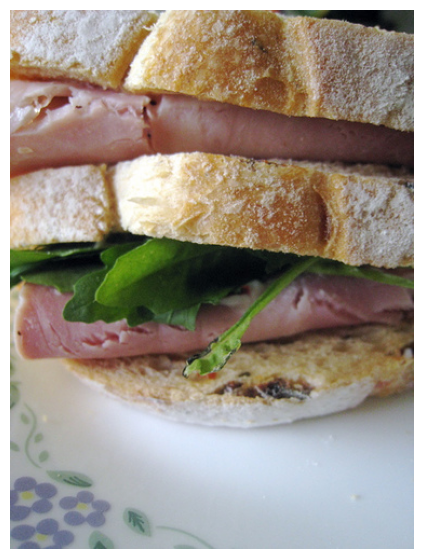

In [7]:
# load and display the image
image = cv2.imread(image_path)

if image is None:
    raise ValueError("Could not load image.")

image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

print("Image shape:", image.shape)

plt.figure(figsize=(10, 7))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [8]:
# find the class configuration
if yaml_files:
    DATA_YAML = yaml_files[0]

    with open(DATA_YAML, "r") as f:
        data_config = yaml.safe_load(f)

    print("Using existing YAML:")
    print(DATA_YAML)
    print("\nConfiguration:")
    print(data_config)

else:
    DATA_YAML = None
    data_config = {}

    print("No YAML found.")

No YAML found.


In [10]:
# get class names
if "names" in data_config:

    class_names = data_config["names"]

    if isinstance(class_names, dict):
        class_names = [
            class_names[i]
            for i in sorted(class_names)
        ]

    print("Number of classes:", len(class_names))

    for i, name in enumerate(class_names):
        print(f"{i:2d} → {name}")

else:

    print("Class names were not found in YAML.")
    print("We need to inspect the dataset configuration before training.")

Class names were not found in YAML.
We need to inspect the dataset configuration before training.


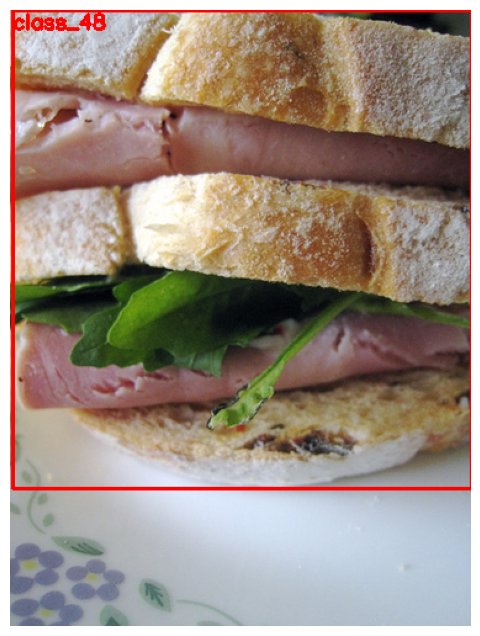

In [11]:
# draw the annotated boxes
display_image = image_rgb.copy()

h, w = display_image.shape[:2]

for line in annotations:

    values = line.strip().split()

    if len(values) != 5:
        continue

    class_id = int(values[0])
    xc = float(values[1])
    yc = float(values[2])
    bw = float(values[3])
    bh = float(values[4])

    # Normalized → pixels
    xc *= w
    yc *= h
    bw *= w
    bh *= h

    # Center → corners
    x1 = int(xc - bw / 2)
    y1 = int(yc - bh / 2)
    x2 = int(xc + bw / 2)
    y2 = int(yc + bh / 2)

    # Keep coordinates inside image
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)

    if "class_names" in globals():
        class_name = class_names[class_id]
    else:
        class_name = f"class_{class_id}"

    cv2.rectangle(
        display_image,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

    cv2.putText(
        display_image,
        class_name,
        (x1, max(y1 - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(12, 8))
plt.imshow(display_image)
plt.axis("off")
plt.show()

In [12]:
# count annoted objects
class_counter = Counter()

valid_label_count = 0

for label_path in label_files:

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:

        values = line.strip().split()

        if len(values) != 5:
            continue

        class_id = int(values[0])

        class_counter[class_id] += 1

    valid_label_count += 1

print("Label files processed:", valid_label_count)
print("Total objects:", sum(class_counter.values()))

print("\nObjects per class:")

for class_id, count in sorted(class_counter.items()):
    
    if "class_names" in globals() and class_id < len(class_names):
        name = class_names[class_id]
    else:
        name = f"class_{class_id}"

    print(f"{class_id:2d} | {name:20s} | {count}")

Label files processed: 29956
Total objects: 218107

Objects per class:
 0 | class_0              | 66241
 1 | class_1              | 1793
 2 | class_2              | 11339
 3 | class_3              | 2307
 4 | class_4              | 1195
 5 | class_5              | 1531
 6 | class_6              | 1285
 7 | class_7              | 2546
 8 | class_8              | 2947
 9 | class_9              | 3476
10 | class_10             | 513
11 | class_11             | 498
12 | class_12             | 373
13 | class_13             | 2581
14 | class_14             | 2644
15 | class_15             | 1234
16 | class_16             | 1384
17 | class_17             | 1652
18 | class_18             | 2273
19 | class_19             | 2133
20 | class_20             | 1377
21 | class_21             | 341
22 | class_22             | 1366
23 | class_23             | 1304
24 | class_24             | 2222
25 | class_25             | 2769
26 | class_26             | 3218
27 | class_27             | 1690
28 | cl

In [13]:
# create subset directories
SUBSET_ROOT = os.path.join(
    os.path.dirname(DATASET_ROOT),
    "stage3_subset"
)

TRAIN_IMG_OUT = os.path.join(
    SUBSET_ROOT,
    "train",
    "images"
)

TRAIN_LBL_OUT = os.path.join(
    SUBSET_ROOT,
    "train",
    "labels"
)

VAL_IMG_OUT = os.path.join(
    SUBSET_ROOT,
    "val",
    "images"
)

VAL_LBL_OUT = os.path.join(
    SUBSET_ROOT,
    "val",
    "labels"
)

for folder in [
    TRAIN_IMG_OUT,
    TRAIN_LBL_OUT,
    VAL_IMG_OUT,
    VAL_LBL_OUT
]:
    os.makedirs(folder, exist_ok=True)

print("Subset folder created:")
print(SUBSET_ROOT)

Subset folder created:
E:\Pyhton code\Data Sets\archive\stage3_subset


In [14]:
# Try to identify train/validation folders from their paths

train_candidates = [
    p for p in image_files
    if any(
        part.lower() in ["train", "training"]
        for part in os.path.normpath(p).split(os.sep)
    )
]

val_candidates = [
    p for p in image_files
    if any(
        part.lower() in ["val", "valid", "validation"]
        for part in os.path.normpath(p).split(os.sep)
    )
]

print("Training candidates  :", len(train_candidates))
print("Validation candidates:", len(val_candidates))

Training candidates  : 0
Validation candidates: 0


In [15]:
# prepare train/vlidation split
random.seed(42)

if len(train_candidates) > 0 and len(val_candidates) > 0:

    source_train = train_candidates
    source_val = val_candidates

else:

    # Dataset has no explicit split.
    # Create our own 80/20 split.
    
    random.shuffle(image_files)

    split_index = int(len(image_files) * 0.8)

    source_train = image_files[:split_index]
    source_val = image_files[split_index:]

print("Training images :", len(source_train))
print("Validation images:", len(source_val))

Training images : 24000
Validation images: 6000


In [16]:
# limit dataset size for laptop training
MAX_TRAIN_IMAGES = 10000
MAX_VAL_IMAGES = 2000

train_subset = random.sample(
    source_train,
    min(MAX_TRAIN_IMAGES, len(source_train))
)

val_subset = random.sample(
    source_val,
    min(MAX_VAL_IMAGES, len(source_val))
)

print("Selected training images :", len(train_subset))
print("Selected validation images:", len(val_subset))

Selected training images : 10000
Selected validation images: 2000


In [17]:
# helper to find a label
def find_label_for_image(image_path):

    stem = os.path.splitext(
        os.path.basename(image_path)
    )[0]

    matches = [
        p for p in label_files
        if os.path.splitext(os.path.basename(p))[0] == stem
    ]

    if matches:
        return matches[0]

    return None


print("Label lookup function ready.")

Label lookup function ready.


In [18]:
# copy training data
copied_train = 0
missing_train_labels = 0

for image_path in train_subset:

    label_path = find_label_for_image(image_path)

    if label_path is None:
        missing_train_labels += 1
        continue

    filename = os.path.basename(image_path)
    label_name = os.path.basename(label_path)

    shutil.copy2(
        image_path,
        os.path.join(TRAIN_IMG_OUT, filename)
    )

    shutil.copy2(
        label_path,
        os.path.join(TRAIN_LBL_OUT, label_name)
    )

    copied_train += 1

print("Training images copied:", copied_train)
print("Missing labels:", missing_train_labels)

Training images copied: 9985
Missing labels: 15


In [19]:
# copy validation data
copied_val = 0
missing_val_labels = 0

for image_path in val_subset:

    label_path = find_label_for_image(image_path)

    if label_path is None:
        missing_val_labels += 1
        continue

    filename = os.path.basename(image_path)
    label_name = os.path.basename(label_path)

    shutil.copy2(
        image_path,
        os.path.join(VAL_IMG_OUT, filename)
    )

    shutil.copy2(
        label_path,
        os.path.join(VAL_LBL_OUT, label_name)
    )

    copied_val += 1

print("Validation images copied:", copied_val)
print("Missing labels:", missing_val_labels)

Validation images copied: 1997
Missing labels: 3


In [21]:
# Create COCO 80-class names directly

class_names = [
    "person", "bicycle", "car", "motorcycle", "airplane",
    "bus", "train", "truck", "boat", "traffic light",
    "fire hydrant", "stop sign", "parking meter", "bench",
    "bird", "cat", "dog", "horse", "sheep", "cow",
    "elephant", "bear", "zebra", "giraffe", "backpack",
    "umbrella", "handbag", "tie", "suitcase", "frisbee",
    "skis", "snowboard", "sports ball", "kite", "baseball bat",
    "baseball glove", "skateboard", "surfboard", "tennis racket",
    "bottle", "wine glass", "cup", "fork", "knife", "spoon",
    "bowl", "banana", "apple", "sandwich", "orange", "broccoli",
    "carrot", "hot dog", "pizza", "donut", "cake", "chair",
    "couch", "potted plant", "bed", "dining table", "toilet",
    "tv", "laptop", "mouse", "remote", "keyboard", "cell phone",
    "microwave", "oven", "toaster", "sink", "refrigerator",
    "book", "clock", "vase", "scissors", "teddy bear",
    "hair drier", "toothbrush"
]

print("Number of classes:", len(class_names))

Number of classes: 80


In [22]:
SUBSET_YAML = os.path.join(
    SUBSET_ROOT,
    "data.yaml"
)

subset_config = {
    "path": os.path.abspath(SUBSET_ROOT),
    "train": "train/images",
    "val": "val/images",
    "names": class_names
}

with open(SUBSET_YAML, "w") as f:
    yaml.dump(
        subset_config,
        f,
        sort_keys=False
    )

print("YAML created successfully.")
print(SUBSET_YAML)

YAML created successfully.
E:\Pyhton code\Data Sets\archive\stage3_subset\data.yaml


In [23]:
print("TRAIN")
print(
    "Images:",
    len(glob.glob(
        os.path.join(
            TRAIN_IMG_OUT,
            "*"
        )
    ))
)

print(
    "Labels:",
    len(glob.glob(
        os.path.join(
            TRAIN_LBL_OUT,
            "*.txt"
        )
    ))
)

print("\nVALIDATION")

print(
    "Images:",
    len(glob.glob(
        os.path.join(
            VAL_IMG_OUT,
            "*"
        )
    ))
)

print(
    "Labels:",
    len(glob.glob(
        os.path.join(
            VAL_LBL_OUT,
            "*.txt"
        )
    )))

print("\nClasses:", len(class_names))
print("YAML:", SUBSET_YAML)

TRAIN
Images: 9985
Labels: 9985

VALIDATION
Images: 1997
Labels: 1997

Classes: 80
YAML: E:\Pyhton code\Data Sets\archive\stage3_subset\data.yaml


In [24]:
#check CUDA/GPU
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("WARNING: CUDA GPU not detected.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 2050
CUDA version: 12.8


In [25]:
#Load YOLO
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("YOLO11n loaded successfully.")

YOLO11n loaded successfully.


In [27]:
# Start training
results = model.train(
    data=SUBSET_YAML,
    epochs=15,
    imgsz=640,
    batch=8,
    device=0,
    workers=2,
    project="runs",
    name="stage3_general_80class",
    pretrained=True,
    patience=5,
    cache=False,
    plots=True
)

New https://pypi.org/project/ultralytics/8.4.121 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.120  Python-3.11.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\Pyhton code\Data Sets\archive\stage3_subset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio

In [28]:
# evaluate model
metrics = model.val(
    data=SUBSET_YAML,
    imgsz=640,
    batch=8,
    device=0
)

print("mAP50    :", metrics.box.map50)
print("mAP50-95 :", metrics.box.map)
print("mAP75    :", metrics.box.map75)

Ultralytics 8.4.120  Python-3.11.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
YOLO11n summary (fused): 101 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 189.177.4 MB/s, size: 133.9 KB)
val: Scanning E:\Pyhton code\Data Sets\archive\stage3_subset\val\labels.cache... 1997 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1997/1997  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 250/250 2.5it/s 1:410.5sss
                   all       1997      14066      0.672      0.525      0.575      0.414
                person       1086       4201      0.821      0.631      0.743      0.508
               bicycle         48         85      0.729      0.494      0.566      0.374
                   car        211        757      0.731      0.486      0.578      0.358
            motorcycle         70        166      0.784      0.612      0.704      0.449
       

In [29]:
# display training result
RESULTS_DIR = "runs/stage3_general_80class"

results_image = os.path.join(
    RESULTS_DIR,
    "results.png"
)

if os.path.exists(results_image):

    img = cv2.imread(results_image)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

else:
    print("results.png not found:")
    print(results_image)

results.png not found:
runs/stage3_general_80class\results.png


In [32]:
import os

print("Current notebook directory:")
print(os.getcwd())

print("\nAll files/folders inside runs:")

if os.path.exists("runs"):
    for root, dirs, files in os.walk("runs"):
        level = root.replace(os.path.abspath("runs"), "").count(os.sep)
        indent = "    " * level

        print(f"{indent}{os.path.basename(root)}/")

        for file in files:
            print(f"{indent}    {file}")
else:
    print("runs folder does not exist.")

Current notebook directory:
e:\Pyhton code\Deep Learning\CNN\Object Detection Project

All files/folders inside runs:
runs/
    detect/
        runs/
            stage3_general_80class/
                args.yaml
                BoxF1_curve.png
                BoxPR_curve.png
                BoxP_curve.png
                BoxR_curve.png
                confusion_matrix.png
                confusion_matrix_normalized.png
                labels.jpg
                results.csv
                results.png
                train_batch0.jpg
                train_batch1.jpg
                train_batch2.jpg
                train_batch6245.jpg
                train_batch6246.jpg
                train_batch6247.jpg
                val_batch0_labels.jpg
                val_batch0_pred.jpg
                val_batch1_labels.jpg
                val_batch1_pred.jpg
                val_batch2_labels.jpg
                val_batch2_pred.jpg
                weights/
                    best.pt
            

In [33]:
import glob

best_models = glob.glob(
    "**/best.pt",
    recursive=True
)

print("best.pt files found:")

for path in best_models:
    print(os.path.abspath(path))

best.pt files found:
e:\Pyhton code\Deep Learning\CNN\Object Detection Project\runs\detect\runs\stage3_general_80class\weights\best.pt


In [34]:
# load best model
BEST_MODEL = os.path.join(
    "runs",
    "detect",
    "runs",
    "stage3_general_80class",
    "weights",
    "best.pt"
)

print("Best model exists:", os.path.exists(BEST_MODEL))
print("Best model path:", os.path.abspath(BEST_MODEL))

best_model = YOLO(BEST_MODEL)

print("Best model loaded successfully.")

Best model exists: True
Best model path: e:\Pyhton code\Deep Learning\CNN\Object Detection Project\runs\detect\runs\stage3_general_80class\weights\best.pt
Best model loaded successfully.


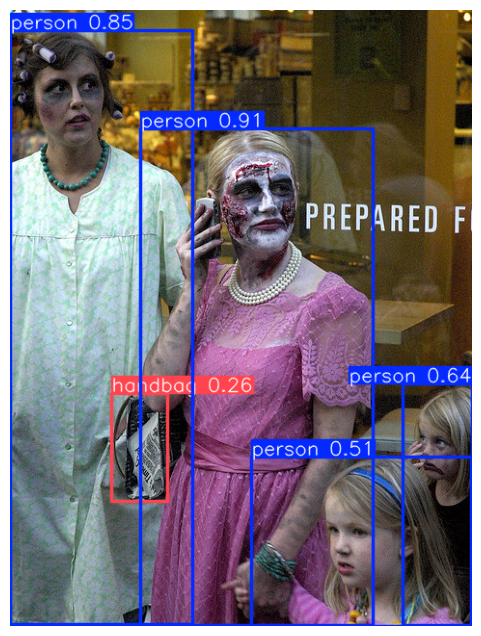

In [35]:
# run inference
test_image = random.choice(val_subset)

prediction = best_model(
    test_image,
    conf=0.25,
    verbose=False
)[0]

annotated = prediction.plot()

plt.figure(figsize=(12, 8))
plt.imshow(
    cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )
)
plt.axis("off")
plt.show()

In [37]:
#print detected object
print("Predictions:\n")

for box in prediction.boxes:

    class_id = int(
        box.cls.item()
    )

    confidence = float(
        box.conf.item()
    )

    print(
        f"{class_names[class_id]:20s}"
        f" confidence={confidence:.3f}"
    )

Predictions:

person               confidence=0.914
person               confidence=0.854
person               confidence=0.642
person               confidence=0.508
handbag              confidence=0.262


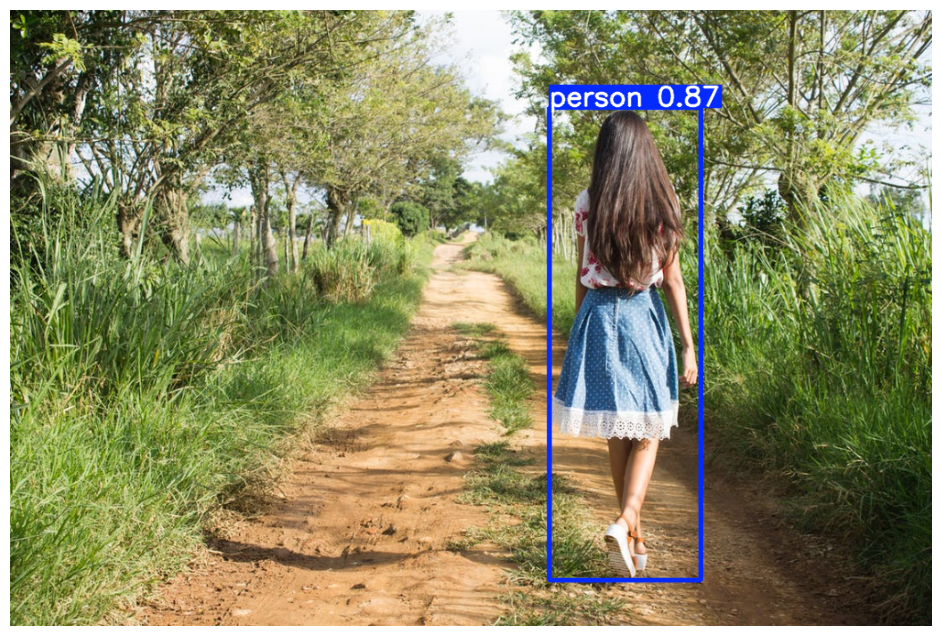

In [ ]:
# real world test
MY_IMAGE = r"C:\Users\SUYASH\OneDrive\Pictures\Screenshots\Screenshot 2026-08-17 124842.png"

prediction = best_model(
    MY_IMAGE,
    conf=0.25,
    verbose=False
)[0]

annotated = prediction.plot()

plt.figure(figsize=(12, 8))
plt.imshow(
    cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )
)
plt.axis("off")
plt.show()

In [40]:
import pandas as pd
import os

results_csv = r"runs\detect\runs\stage3_general_80class\results.csv"

df = pd.read_csv(results_csv)

print("Available metrics:")
print(df.columns.tolist())

print("\nFinal epoch:")
display(df.tail(1).T)

Available metrics:
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

Final epoch:


,5
epoch,6.00000
time,5080.78000
train/box_loss,1.17437
train/cls_loss,1.32046
train/dfl_loss,1.21235
metrics/precision(B),0.62660
metrics/recall(B),0.48260
metrics/mAP50(B),0.52472
metrics/mAP50-95(B),0.36833
val/box_loss,1.15854


In [41]:
print("Best validation mAP50-95:",
      df["metrics/mAP50-95(B)"].max())

print("Best validation mAP50:",
      df["metrics/mAP50(B)"].max())

print("Best precision:",
      df["metrics/precision(B)"].max())

print("Best recall:",
      df["metrics/recall(B)"].max())

Best validation mAP50-95: 0.41361
Best validation mAP50: 0.575
Best precision: 0.67097
Best recall: 0.52513


In [42]:
precision = df["metrics/precision(B)"]
recall = df["metrics/recall(B)"]

f1 = 2 * (precision * recall) / (
    precision + recall + 1e-8
)

print("Best F1:", f1.max())
print("Epoch of best F1:", f1.idxmax() + 1)

Best F1: 0.5891588883106856
Epoch of best F1: 1
